In [1]:
!pip uninstall -y torch torchvision torchaudio transformers tokenizers
%pip install torch==2.4.1 torchvision==0.19.1 transformers==4.44.2 tqdm pandas --no-cache-dir

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 MB 315.5 kB/s  0:02:35m0:00:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 279.4 kB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 479.1 kB/s  0:00:19 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 338.9 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 465.5 kB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 245.7 kB/s  0:00:09 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [transformers] [transformers]ub]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


In [4]:
if torch.cuda.is_available():
    print(f"GPU aktywne: {torch.cuda.get_device_name(0)}")
    device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS aktywne (Mac)")
    device = "mps"
else:
    print("Działa tylko CPU. Sprawdź ustawienia instancji.")
    device = "cpu"

MPS aktywne (Mac)


In [5]:
classifier = pipeline(
    "text-classification",
    model="monologg/bert-base-cased-goemotions-original",
    top_k=None,
    device=device,
    token=os.getenv("HF_TOKEN"),
)

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
df = pd.read_csv("../../../data/cleaned_data.csv")
texts = df['cleaned_statement'].astype(str).tolist()

In [7]:
results = []
for out in tqdm(classifier(texts, batch_size=16, truncation=True), total=len(texts)):
    results.append(out)

100%|██████████| 31985/31985 [00:00<00:00, 1820727.09it/s]


In [8]:
extracted_data = []
for res in results:
    row = {item['label']: item['score'] for item in res}
    extracted_data.append(row)

In [9]:
features_df = pd.DataFrame(extracted_data)

In [10]:
if 'label' in df.columns:
    features_df['target_label'] = df['label'].values

features_df.to_csv('../../../data/features_for_model.csv', index=False)

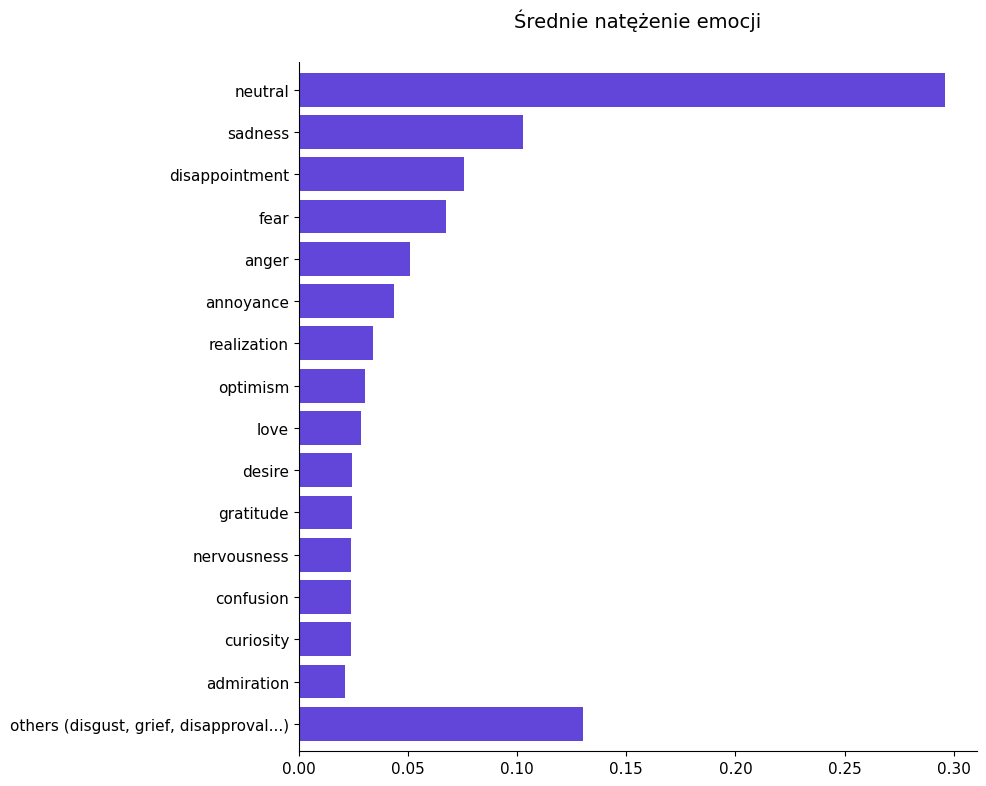

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

BRAND_COLOR = '#6146d9ff'
THRESHOLD = 0.02 
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

means = features_df.drop(columns=['target_label'], errors='ignore').mean()

main_emotions = means[means >= THRESHOLD].sort_values(ascending=True) # Ascending=True, żeby najwyższe były na górze w barh
others = means[means < THRESHOLD]

if not others.empty:
    others_list = others.index.tolist()
    others_names_limited = ", ".join(others_list[:3]) + "..."
    label_others = f"others ({others_names_limited})"
    others_series = pd.Series({label_others: others.sum()})
    final_data = pd.concat([others_series, main_emotions])
else:
    final_data = main_emotions

plt.figure(figsize=(10, 8))
ax = final_data.plot(
    kind='barh', 
    color=BRAND_COLOR, 
    width=0.8
)

plt.title('Średnie natężenie emocji', pad=25, fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()